# Dự báo Doanh thu Sản phẩm
## 7. Đánh giá Mô hình trên Tập Kiểm Thử (Test Set Evaluation)

Chúng ta đánh giá khả năng dự báo trên tập kiểm thử thời gian (Time-based Test Set) từ tháng 11/2022 trở đi.

In [17]:
import pandas as pd
import numpy as np
import joblib
import os
import time
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

READY_DATA_DIR = r'../data/ready_for_train'
X_test = joblib.load(os.path.join(READY_DATA_DIR, 'X_test.pkl'))
y_test = joblib.load(os.path.join(READY_DATA_DIR, 'y_test.pkl'))
print('Kích thước tập kiểm thử:', X_test.shape)

Kích thước tập kiểm thử: (1313, 17)


### 7.1 Định nghĩa import lớp để deserialize LightGBM Scratch

In [18]:
import sys, os
sys.path.append(os.path.abspath(os.path.join('..', '..', '..')))
from practice_2.complete_solution.utils.models import LightGBMFromScratch
sys.modules['__main__'].LightGBMFromScratch = LightGBMFromScratch

### 7.2 Tính toán các chỉ số dự báo

In [19]:
model_names = ['HistGradientBoosting', 'XGBoost', 'LightGBM', 'CatBoost', 'LightGBM_Scratch']
fit_times = joblib.load(os.path.join(READY_DATA_DIR, 'fit_times.pkl'))
categorical_cols = ['category', 'shopping_mall']

X_test_cat = X_test.copy()
for col in categorical_cols:
    X_test_cat[col] = X_test_cat[col].astype('category')

results = []
all_preds = {}

for name in model_names:
    clean_name = name.lower()
    model_path = os.path.join(READY_DATA_DIR, f'model_{clean_name}.pkl')
    model = joblib.load(model_path)
    
    start_pred = time.time()
    if name in ['LightGBM', 'XGBoost']:
        preds = model.predict(X_test_cat)
    elif name == 'LightGBM_Scratch':
        preds = model.predict(X_test.values)
    else:
        preds = model.predict(X_test)
    pred_time_ms = (time.time() - start_pred) * 1000
    
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    
    original_name = 'LightGBM (Scratch)' if name == 'LightGBM_Scratch' else name
    results.append({
        'Model': original_name,
        'MAE': mae,
        'RMSE': rmse,
        'R2 Score': r2,
        'Fit Time (s)': fit_times[original_name],
        'Predict Time (ms)': pred_time_ms
    })
    all_preds[original_name] = preds

results_df = pd.DataFrame(results).sort_values(by='R2 Score', ascending=False)
print(results_df)

                  Model          MAE         RMSE  R2 Score  Fit Time (s)  \
0  HistGradientBoosting  1885.308299  4368.728279  0.877882      0.517330   
1               XGBoost  1998.276454  4418.574237  0.875079      0.237356   
2              LightGBM  1914.080833  4431.192805  0.874365      0.290253   
3              CatBoost  2065.461795  4456.272421  0.872939      0.244585   
4    LightGBM (Scratch)  2035.060906  4504.846760  0.870153      1.879028   

   Predict Time (ms)  
0          99.199057  
1          13.108015  
2           7.771015  
3          22.429943  
4           6.832123  


### 7.3 Trực quan hóa Actual vs Predicted Demand Over Time
Chúng ta vẽ biểu đồ so sánh doanh thu tuần thực tế so với doanh thu tuần dự đoán của mô hình tốt nhất trên tập kiểm thử.
Để đánh giá toàn diện và trực quan nhất khả năng dự báo của mô hình trên nhiều cửa hàng và mọi ngành hàng, chúng ta vẽ **lưới biểu đồ 3x3 (9 phân nhóm)** bao phủ toàn bộ **8 ngành hàng** và **8 trung tâm thương mại** khác nhau từ quy mô doanh số lớn đến nhỏ:
1. **Clothing tại Mall of Istanbul** (Doanh số lớn nhất)
2. **Technology tại Kanyon** (Công nghệ - Kanyon)
3. **Shoes tại Istinye Park** (Giày dép - Istinye Park)
4. **Cosmetics tại Metrocity** (Mỹ phẩm - Metrocity)
5. **Toys tại Forum Istanbul** (Đồ chơi - Forum Istanbul)
6. **Books tại Cevahir AVM** (Sách - Cevahir AVM)
7. **Food & Beverage tại Zorlu Center** (Thực phẩm & Đồ uống - Zorlu Center)
8. **Souvenir tại Viaport Outlet** (Quà lưu niệm - Viaport Outlet)
9. **Clothing tại Metropol AVM** (Quần áo - Metropol AVM)

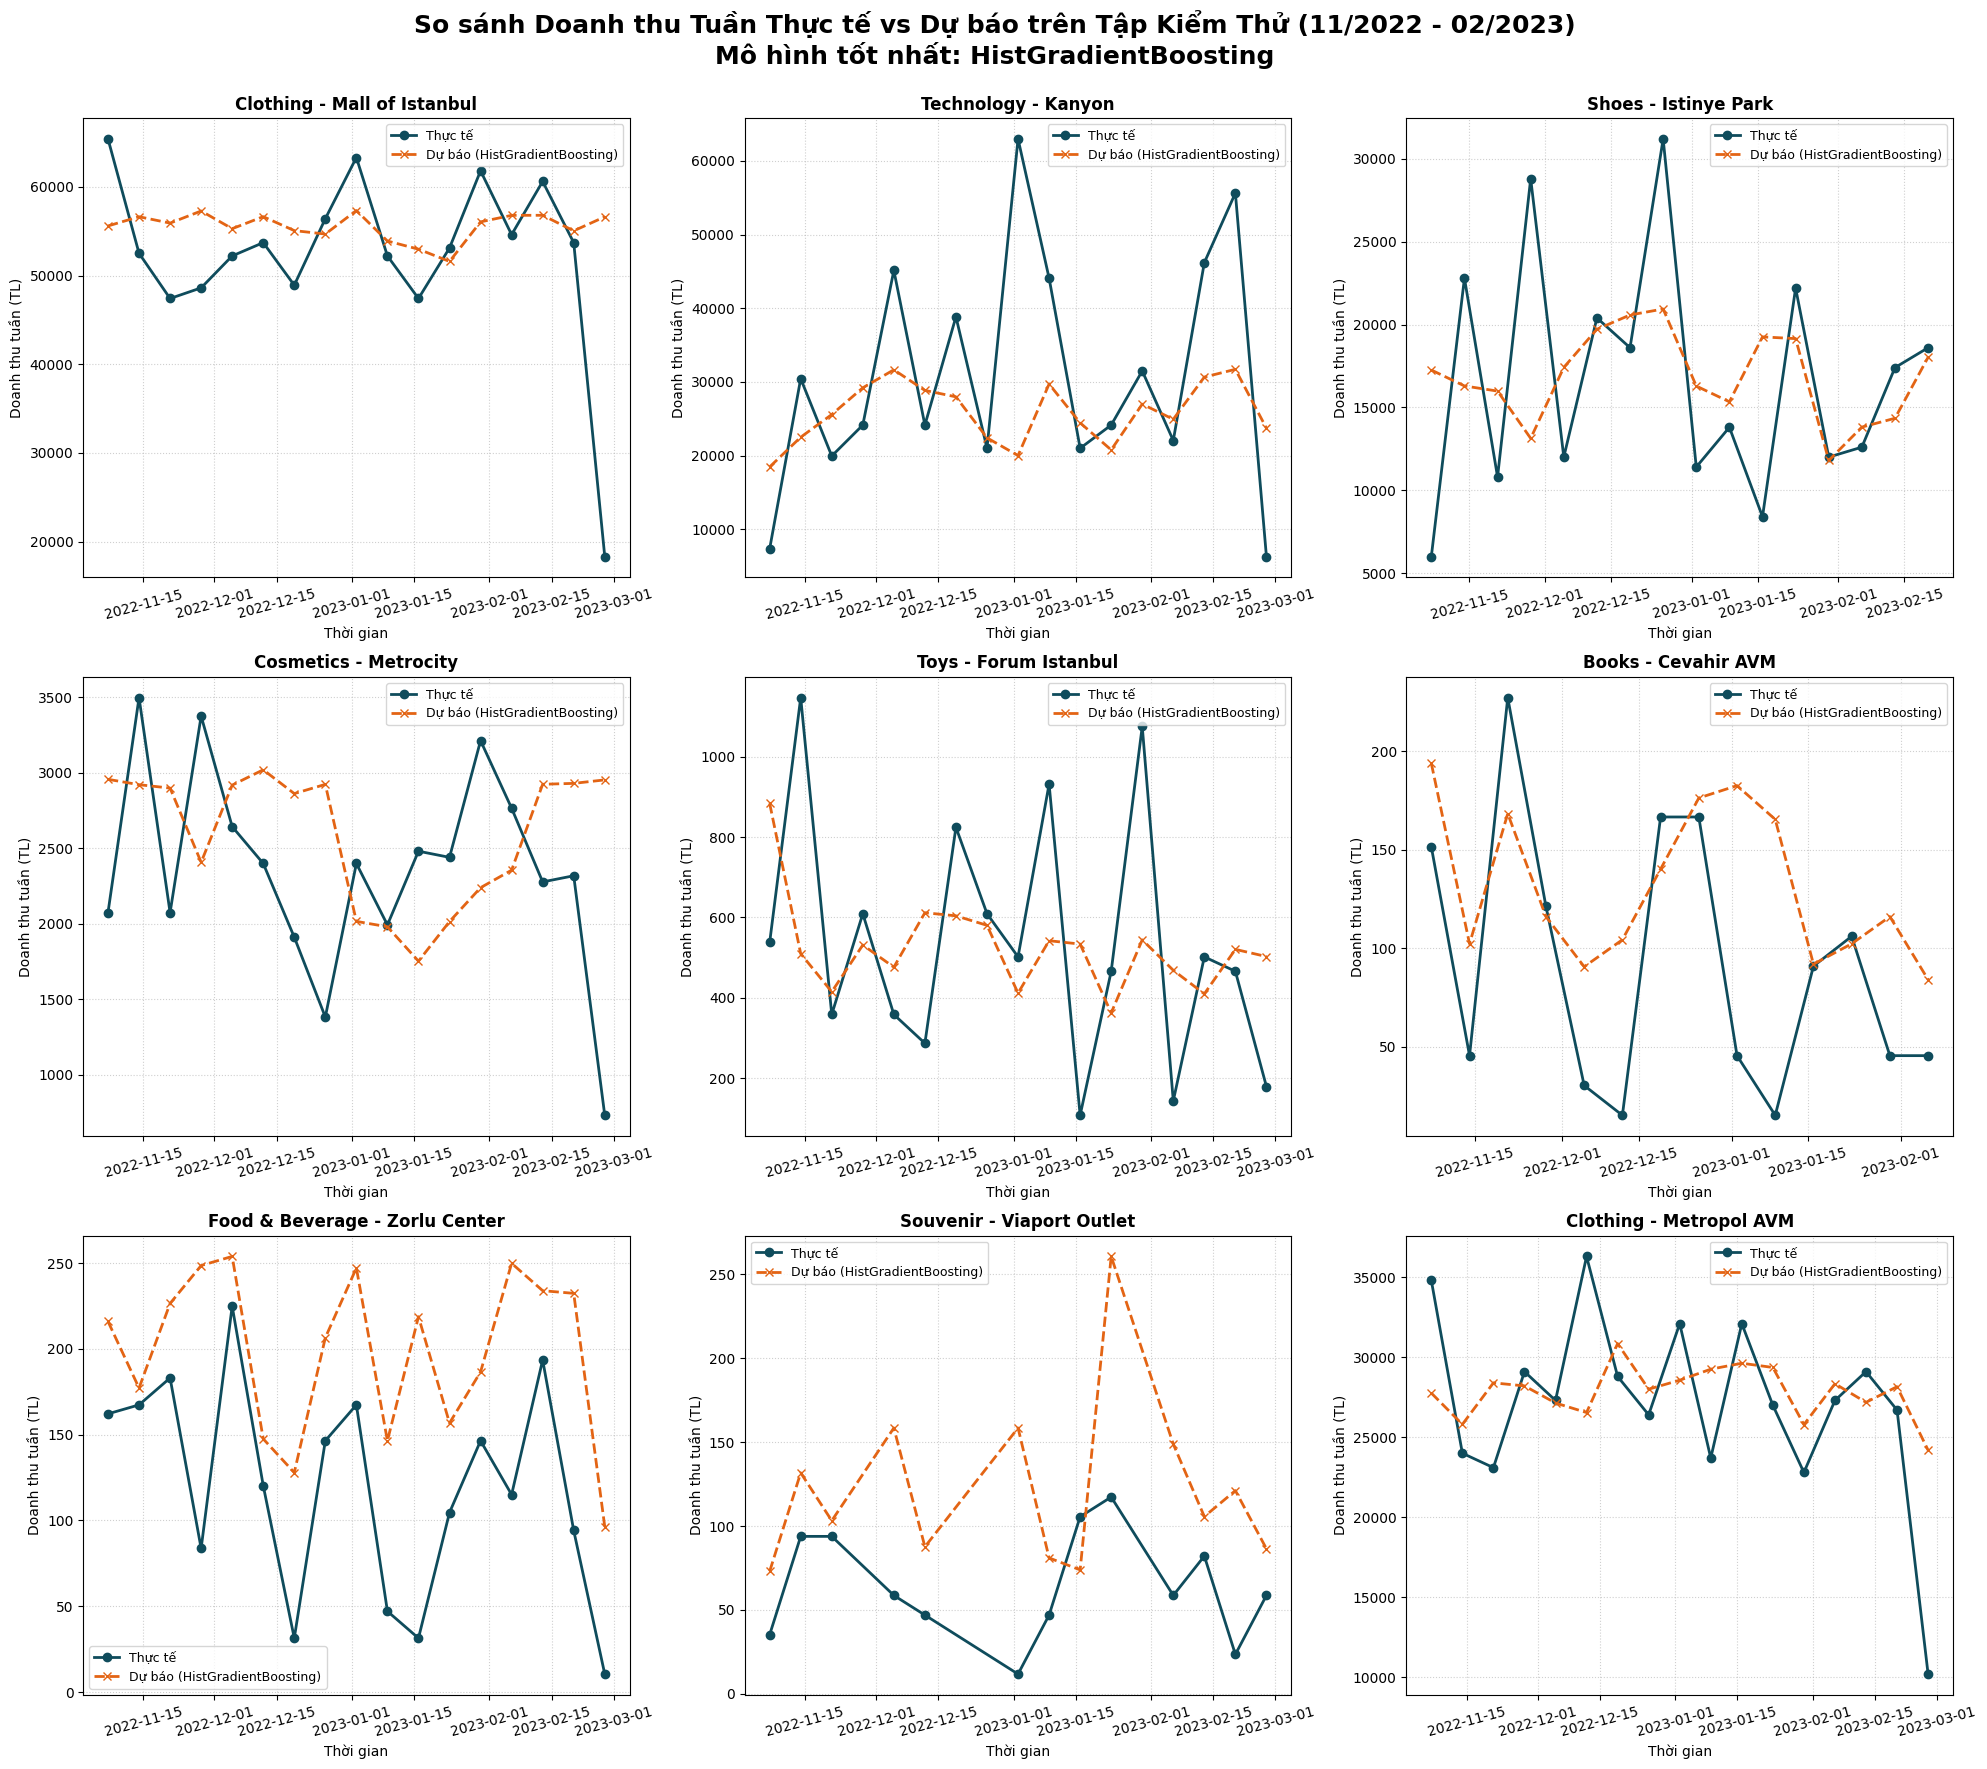

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tái lập test_orig từ file dữ liệu gốc gộp tuần
CLEANED_DATA_PATH = r'../data/preprocessed-data/preprocessed_customer_shopping_data.csv'
df_orig = pd.read_csv(CLEANED_DATA_PATH, parse_dates=['invoice_date'])
df_orig = df_orig.sort_values(by=['category', 'shopping_mall', 'invoice_date']).reset_index(drop=True)
df_orig['Sales_Revenue_Lag1'] = df_orig.groupby(['category', 'shopping_mall'])['Sales_Revenue'].shift(1)
df_clean = df_orig.dropna().reset_index(drop=True)
test_orig = df_clean[df_clean['invoice_date'] >= '2022-11-01'].copy().reset_index(drop=True)

# Thêm dự đoán của mô hình tốt nhất (ví dụ: HistGradientBoosting)
best_model_name = results_df.iloc[0]['Model']
test_orig['Pred_Sales'] = all_preds[best_model_name]

# Định nghĩa 9 nhóm ngành hàng - trung tâm thương mại đại diện
plot_groups = [
    {"category": "Clothing", "shopping_mall": "Mall of Istanbul", "title": "Clothing - Mall of Istanbul"},
    {"category": "Technology", "shopping_mall": "Kanyon", "title": "Technology - Kanyon"},
    {"category": "Shoes", "shopping_mall": "Istinye Park", "title": "Shoes - Istinye Park"},
    {"category": "Cosmetics", "shopping_mall": "Metrocity", "title": "Cosmetics - Metrocity"},
    {"category": "Toys", "shopping_mall": "Forum Istanbul", "title": "Toys - Forum Istanbul"},
    {"category": "Books", "shopping_mall": "Cevahir AVM", "title": "Books - Cevahir AVM"},
    {"category": "Food & Beverage", "shopping_mall": "Zorlu Center", "title": "Food & Beverage - Zorlu Center"},
    {"category": "Souvenir", "shopping_mall": "Viaport Outlet", "title": "Souvenir - Viaport Outlet"},
    {"category": "Clothing", "shopping_mall": "Metropol AVM", "title": "Clothing - Metropol AVM"}
]

fig, axes = plt.subplots(3, 3, figsize=(20, 18))
axes_flat = axes.flatten()

for idx, group in enumerate(plot_groups):
    ax = axes_flat[idx]
    cat = group["category"]
    mall = group["shopping_mall"]
    title_text = group["title"]
    
    # Lọc dữ liệu
    plot_df = test_orig[(test_orig['category'] == cat) & (test_orig['shopping_mall'] == mall)]
    plot_df = plot_df.sort_values(by='invoice_date')
    
    # Vẽ biểu đồ
    ax.plot(plot_df['invoice_date'], plot_df['Sales_Revenue'], marker='o', label='Thực tế', color='#0f4c5c', linewidth=2)
    ax.plot(plot_df['invoice_date'], plot_df['Pred_Sales'], marker='x', linestyle='--', label=f'Dự báo ({best_model_name})', color='#e36414', linewidth=2)
    
    ax.set_title(title_text, fontsize=12, fontweight='bold')
    ax.set_xlabel('Thời gian', fontsize=10)
    ax.set_ylabel('Doanh thu tuần (TL)', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, linestyle=':', alpha=0.6)
    
    # Xoay nhãn ngày tháng để không bị đè lên nhau
    ax.tick_params(axis='x', rotation=15)

plt.suptitle(f'So sánh Doanh thu Tuần Thực tế vs Dự báo trên Tập Kiểm Thử (11/2022 - 02/2023)\nMô hình tốt nhất: {best_model_name}', fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()